In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir("/content/drive/MyDrive/Master/AINC/Project/Unifews")

Mounted at /content/drive


Best epoch info:
epoch         7.000000
train_loss    0.396200
val_acc       0.871200
time          0.488300
macs          7.809200
loss_ma10     0.935371
acc_ma10      0.800543
Name: 6, dtype: float64


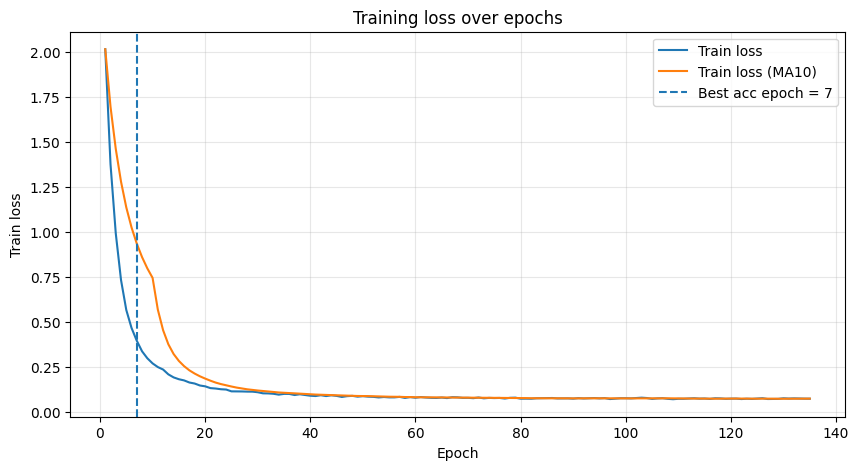

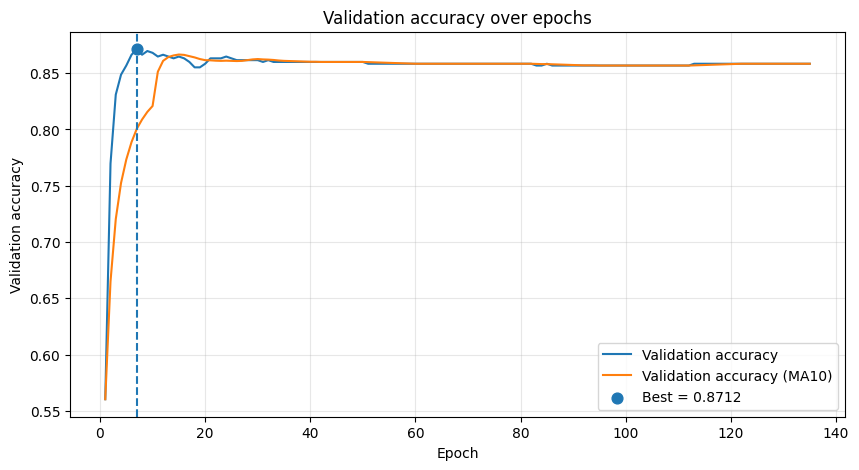

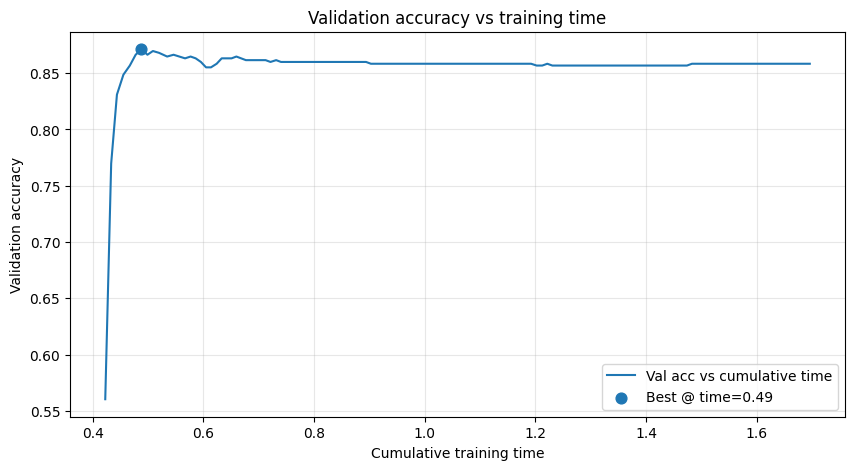

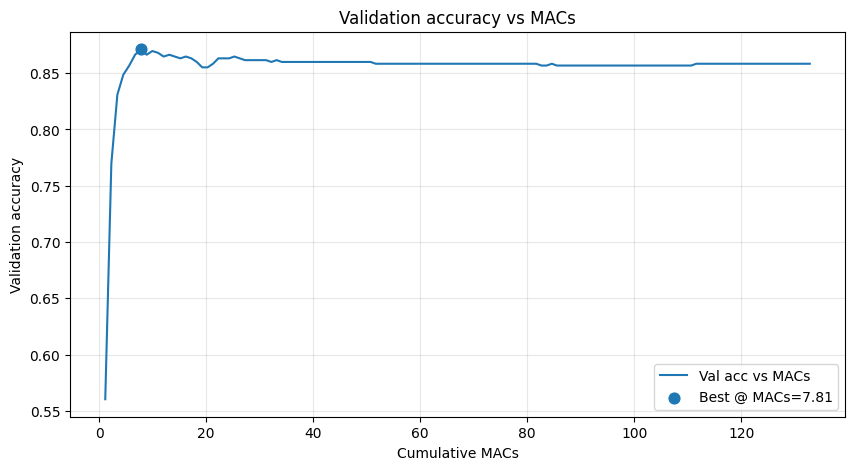

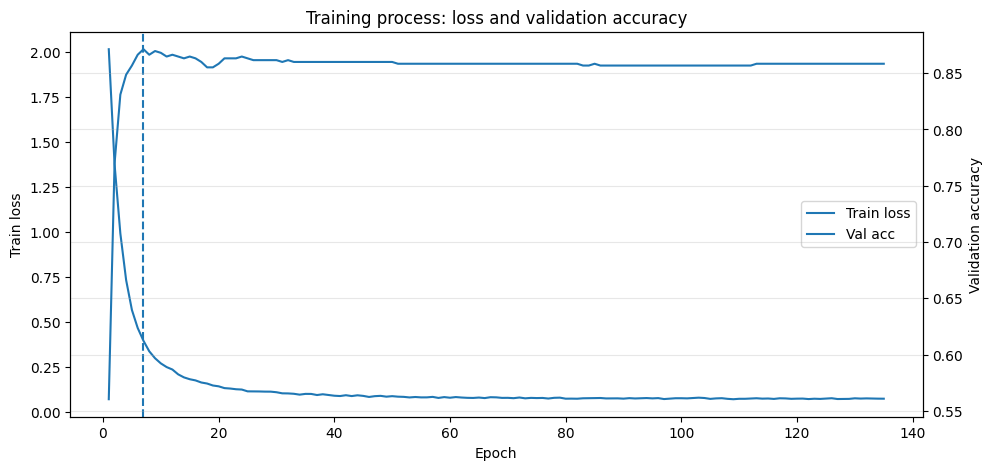

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# ===== 1. Đọc file log =====
log_path = "/content/drive/MyDrive/Master/AINC/Project/Unifews/save/cora/gcn_thr/42-4.0e-01-5.0e-01/log.txt"   # đổi đường dẫn nếu cần

pattern = re.compile(
    r"Epoch:(\d+)\s*\|\s*train loss:(\d+\.\d+),\s*val acc:(\d+\.\d+),\s*time:(\d+\.\d+),\s*macs:(\d+\.\d+)"
)

rows = []
with open(log_path, "r", encoding="utf-8") as f:
    for line in f:
        m = pattern.search(line)
        if m:
            rows.append({
                "epoch": int(m.group(1)),
                "train_loss": float(m.group(2)),
                "val_acc": float(m.group(3)),
                "time": float(m.group(4)),
                "macs": float(m.group(5)),
            })

df = pd.DataFrame(rows)

# ===== 2. Tính thêm cột mượt =====
df["loss_ma10"] = df["train_loss"].rolling(10, min_periods=1).mean()
df["acc_ma10"]  = df["val_acc"].rolling(10, min_periods=1).mean()

best_idx = df["val_acc"].idxmax()
best_row = df.loc[best_idx]

print("Best epoch info:")
print(best_row)

# ===== 3. Plot 1: Train loss theo epoch =====
plt.figure(figsize=(10, 5))
plt.plot(df["epoch"], df["train_loss"], label="Train loss")
plt.plot(df["epoch"], df["loss_ma10"], label="Train loss (MA10)")
plt.axvline(best_row["epoch"], linestyle="--", label=f'Best acc epoch = {int(best_row["epoch"])}')
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("Training loss over epochs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ===== 4. Plot 2: Validation accuracy theo epoch =====
plt.figure(figsize=(10, 5))
plt.plot(df["epoch"], df["val_acc"], label="Validation accuracy")
plt.plot(df["epoch"], df["acc_ma10"], label="Validation accuracy (MA10)")
plt.scatter([best_row["epoch"]], [best_row["val_acc"]], s=60, label=f'Best = {best_row["val_acc"]:.4f}')
plt.axvline(best_row["epoch"], linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Validation accuracy over epochs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ===== 5. Plot 3: Accuracy theo thời gian train tích luỹ =====
plt.figure(figsize=(10, 5))
plt.plot(df["time"], df["val_acc"], label="Val acc vs cumulative time")
plt.scatter([best_row["time"]], [best_row["val_acc"]], s=60, label=f'Best @ time={best_row["time"]:.2f}')
plt.xlabel("Cumulative training time")
plt.ylabel("Validation accuracy")
plt.title("Validation accuracy vs training time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ===== 6. Plot 4: Accuracy theo MACs =====
plt.figure(figsize=(10, 5))
plt.plot(df["macs"], df["val_acc"], label="Val acc vs MACs")
plt.scatter([best_row["macs"]], [best_row["val_acc"]], s=60, label=f'Best @ MACs={best_row["macs"]:.2f}')
plt.xlabel("Cumulative MACs")
plt.ylabel("Validation accuracy")
plt.title("Validation accuracy vs MACs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ===== 7. Plot 5: Ghép loss + acc chung 1 hình, 2 trục =====
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(df["epoch"], df["train_loss"], label="Train loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train loss")

ax2 = ax1.twinx()
ax2.plot(df["epoch"], df["val_acc"], label="Val acc")
ax2.set_ylabel("Validation accuracy")

ax1.axvline(best_row["epoch"], linestyle="--")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

plt.title("Training process: loss and validation accuracy")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Master/AINC/Project/Unifews/save/cora/log.csv')
df

,Data,Model,Seed,ThA,ThW,Acc,Cn,EP,Ttrain,Ctrain,Ttest,CTest,NumelA,NumelW
0,cora,gcn_thr,42,0.0,0.0,0.89550,6,200,3.5016,371.390,0.0053,1.8569,25.246,737.280
1,cora,gcn_thr,42,0.2,0.0,0.89389,6,200,2.5537,371.251,0.0067,1.8563,24.456,737.280
2,cora,gcn_thr,42,0.4,0.0,0.88103,5,200,2.5948,370.717,0.0054,1.8536,21.492,737.280
3,cora,gcn_thr,42,0.8,0.0,0.86495,19,200,2.5096,369.365,0.0053,1.8469,13.758,737.280
4,cora,gcn_thr,42,1.0,0.0,0.85852,28,200,2.5221,368.670,0.0050,1.8434,10.273,737.280
5,cora,gcn_thr,42,1.1,0.0,0.85691,56,200,2.5293,368.396,0.0051,1.8420,8.951,737.280
6,cora,gcn_thr,42,1.2,0.0,0.85531,30,200,2.4736,368.182,0.0056,1.8409,7.997,737.280
7,cora,gcn_thr,42,1.3,0.0,0.86977,38,200,2.6021,368.010,0.0050,1.8400,7.208,737.280
8,cora,gcn_thr,42,1.4,0.0,0.86817,21,200,2.3788,367.878,0.0048,1.8394,6.681,737.280
9,cora,gcn_thr,42,1.5,0.0,0.87460,28,200,2.5396,367.772,0.0050,1.8388,6.206,737.280


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Đọc file log
# =========================
df.columns = [c.strip() for c in df.columns]

# Chuẩn hoá text nếu cần
for col in ["Data", "Model"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# =========================
# 2. Xoá dòng trùng theo (ThA, ThW), giữ dòng đầu
# =========================
df = df.drop_duplicates(subset=["ThA", "ThW"], keep="first").copy()

# =========================
# 3. Bổ sung FLOP
# FLOP = 2 * MAC
# =========================
if "CTest" in df.columns:
    df["FLOPs_test"] = 2 * df["CTest"]

if "Ctrain" in df.columns:
    df["FLOPs_train"] = 2 * df["Ctrain"]

# =========================
# 4. Tạo cột đối tượng thí nghiệm
# =========================
df["Object"] = df.apply(lambda r: f"(ThA={r['ThA']}, ThW={r['ThW']})", axis=1)

# Sắp xếp cho dễ nhìn
df = df.sort_values(["ThW", "ThA"]).reset_index(drop=True)

# =========================
# 5. Accuracy khi thay đổi ThA, cố định ThW = 0
# =========================
df_tha = df[df["ThW"] == 0].sort_values("ThA")

# =========================
# 6. Accuracy khi thay đổi ThW, cố định ThA = 0
# =========================
df_thw = df[df["ThA"] == 0].sort_values("ThW")

import matplotlib.pyplot as plt

# =========================
# Chuẩn hoá tên cột hiển thị
# =========================
df_tha_plot = df_tha.rename(columns={
    "ThA": "Ngưỡng cắt tỉa cạnh",
    "NumelA": "Số phần tử cạnh còn lại",
    "Acc": "Độ chính xác"
}).copy()

df_thw_plot = df_thw.rename(columns={
    "ThW": "Ngưỡng cắt tỉa trọng số",
    "NumelW": "Số phần tử trọng số còn lại",
    "Acc": "Độ chính xác"
}).copy()

# =========================
# Hàm vẽ biểu đồ cột + đường
# =========================
def plot_numel_accuracy(df, x_col, bar_col, line_col, xlabel, title):
    fig, ax1 = plt.subplots(figsize=(9, 5))

    # Biểu đồ cột
    ax1.bar(df[x_col].astype(str), df[bar_col], alpha=0.7)
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(bar_col)
    ax1.grid(True, axis="y", alpha=0.3)

    # Biểu đồ đường
    ax2 = ax1.twinx()
    ax2.plot(df[x_col].astype(str), df[line_col], marker="o")
    ax2.set_ylabel(line_col)
    ax2.set_ylim(0, 1)

    plt.title(title)
    plt.tight_layout()
    plt.show()

# =========================
# Vẽ khi thay đổi ngưỡng cạnh
# =========================
plot_numel_accuracy(
    df=df_tha_plot,
    x_col="Ngưỡng cắt tỉa cạnh",
    bar_col="Số phần tử cạnh còn lại",
    line_col="Độ chính xác",
    xlabel="Ngưỡng cắt tỉa cạnh (giữ cố định ngưỡng cắt tỉa trọng số = 0)",
    title="Ảnh hưởng của ngưỡng cắt tỉa cạnh đến số phần tử cạnh còn lại và độ chính xác"
)


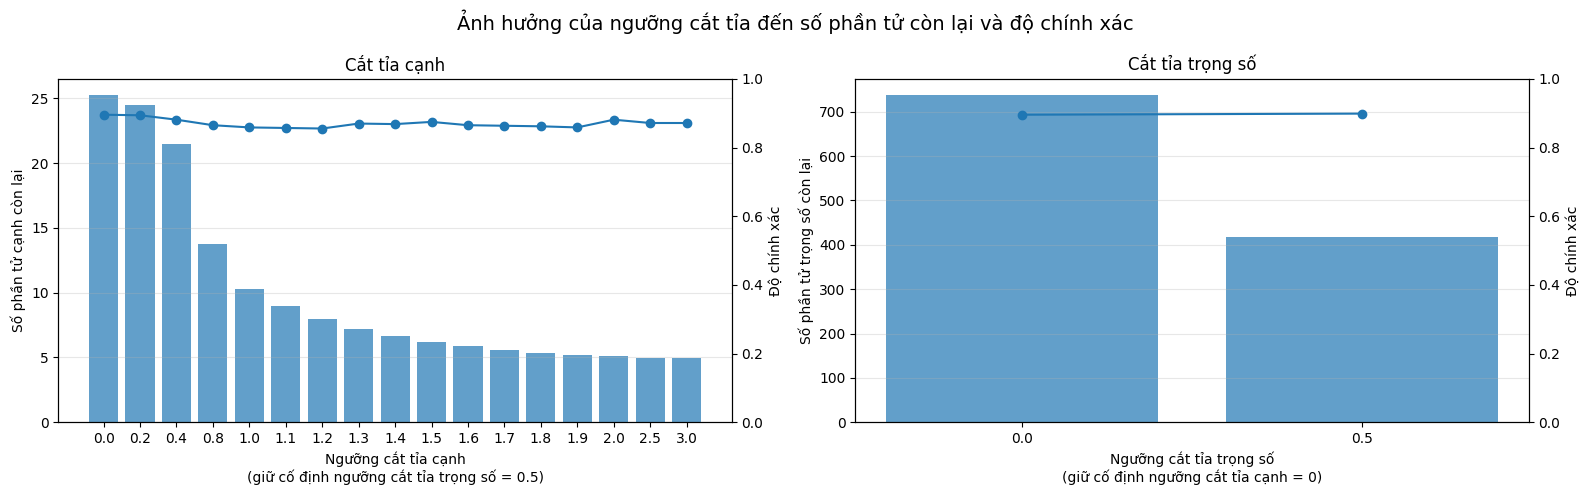

In [ ]:

# =========================
# Chuẩn hoá tên cột hiển thị
# =========================
df_tha_plot = df_tha.rename(columns={
    "ThA": "Ngưỡng cắt tỉa cạnh",
    "NumelA": "Số phần tử cạnh còn lại",
    "Acc": "Độ chính xác"
}).copy()

df_thw_plot = df_thw.rename(columns={
    "ThW": "Ngưỡng cắt tỉa trọng số",
    "NumelW": "Số phần tử trọng số còn lại",
    "Acc": "Độ chính xác"
}).copy()

# =========================
# Tạo 1 hình gồm 2 biểu đồ
# =========================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ---- Biểu đồ 1: thay đổi ngưỡng cắt tỉa cạnh
ax1 = axes[0]
ax1.bar(
    df_tha_plot["Ngưỡng cắt tỉa cạnh"].astype(str),
    df_tha_plot["Số phần tử cạnh còn lại"],
    alpha=0.7
)
ax1.set_xlabel("Ngưỡng cắt tỉa cạnh\n(giữ cố định ngưỡng cắt tỉa trọng số = 0.5)")
ax1.set_ylabel("Số phần tử cạnh còn lại")
ax1.set_title("Cắt tỉa cạnh")
ax1.grid(True, axis="y", alpha=0.3)

ax1_twin = ax1.twinx()
ax1_twin.plot(
    df_tha_plot["Ngưỡng cắt tỉa cạnh"].astype(str),
    df_tha_plot["Độ chính xác"],
    marker="o"
)
ax1_twin.set_ylabel("Độ chính xác")
ax1_twin.set_ylim(0, 1)   # cố định range accuracy từ 0 đến 1

# ---- Biểu đồ 2: thay đổi ngưỡng cắt tỉa trọng số
ax2 = axes[1]
ax2.bar(
    df_thw_plot["Ngưỡng cắt tỉa trọng số"].astype(str),
    df_thw_plot["Số phần tử trọng số còn lại"],
    alpha=0.7
)
ax2.set_xlabel("Ngưỡng cắt tỉa trọng số\n(giữ cố định ngưỡng cắt tỉa cạnh = 0)")
ax2.set_ylabel("Số phần tử trọng số còn lại")
ax2.set_title("Cắt tỉa trọng số")
ax2.grid(True, axis="y", alpha=0.3)

ax2_twin = ax2.twinx()
ax2_twin.plot(
    df_thw_plot["Ngưỡng cắt tỉa trọng số"].astype(str),
    df_thw_plot["Độ chính xác"],
    marker="o"
)
ax2_twin.set_ylabel("Độ chính xác")
ax2_twin.set_ylim(0, 1)   # cố định range accuracy từ 0 đến 1

# ---- Tiêu đề chung
fig.suptitle(
    "Ảnh hưởng của ngưỡng cắt tỉa đến số phần tử còn lại và độ chính xác",
    fontsize=14
)

plt.tight_layout()
plt.show()

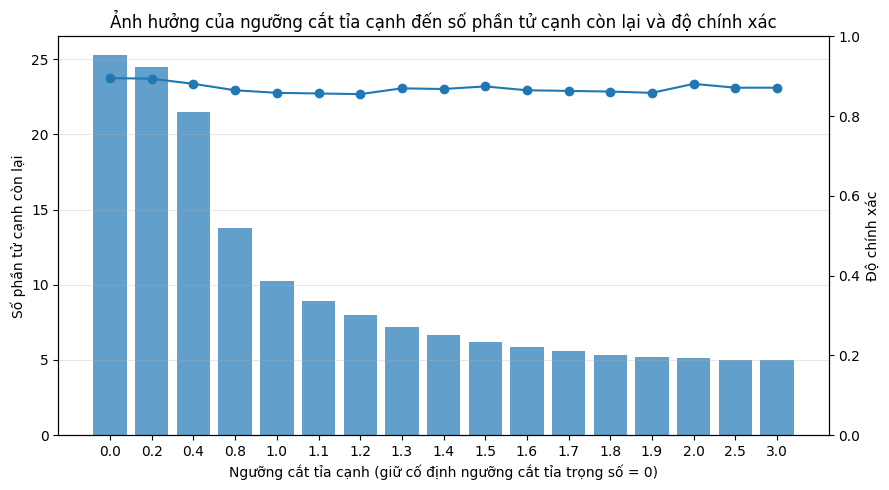

=== df (ThW = 0) ===
   ThA  ThW      Acc   NumelA
0  0.0  0.0  0.91099  983.444
1  0.2  0.0  0.91041  823.781
2  0.4  0.0  0.90460  574.295
3  0.8  0.0  0.89674  270.420
4  1.0  0.0  0.86387  201.062

=== df1 (ThW = 0.5) ===
   ThA  ThW      Acc   NumelA
0  0.2  0.5  0.90809  863.829
1  0.4  0.5  0.90954  642.652
2  0.8  0.5  0.90285  300.011
3  1.0  0.5  0.88889  214.574
4  1.2  0.5  0.85108  158.656

=== Dữ liệu dùng để vẽ ===
    Ngưỡng cắt tỉa cạnh  Số phần tử cạnh còn lại  Độ chính xác (ThW = 0)  \
0                   0.2                  823.781                 0.91041   
1                   0.4                  574.295                 0.90460   
2                   0.8                  270.420                 0.89674   
3                   1.0                  201.062                 0.86387   
4                   1.2                  155.198                 0.85398   
5                   1.4                  123.302                 0.84031   
6                   1.6           

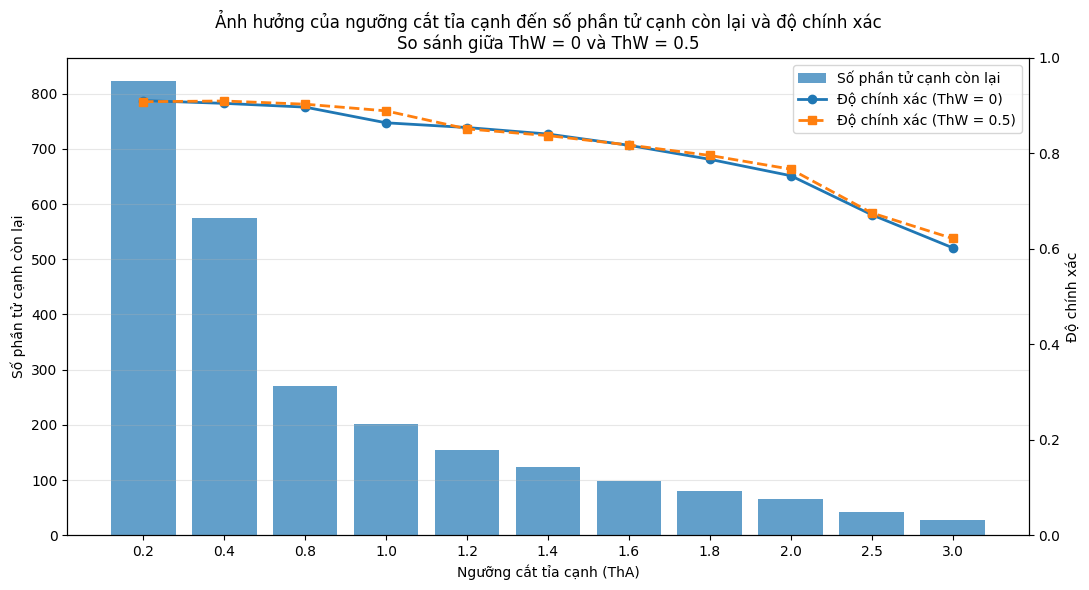

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. Đọc file
# =========================================================
# Đổi lại đường dẫn file cho đúng
file_df  = "/content/drive/MyDrive/Master/AINC/Project/Unifews/save/computers/log.csv"
file_df1 = "/content/drive/MyDrive/Master/AINC/Project/Unifews/save/computers/log_computer.csv"

df = pd.read_csv(file_df)
df1 = pd.read_csv(file_df1)

# =========================================================
# 2. Hàm chuẩn hoá dataframe
# =========================================================
def prepare_dataframe(data):
    data = data.copy()

    # Xoá khoảng trắng ở tên cột
    data.columns = [c.strip() for c in data.columns]

    # Chuẩn hoá text nếu có
    for col in ["Data", "Model"]:
        if col in data.columns:
            data[col] = data[col].astype(str).str.strip()

    # Chuyển các cột số về numeric nếu tồn tại
    numeric_cols = [
        "Seed", "ThA", "ThW", "Acc", "Cn", "EP",
        "Ttrain", "Ctrain", "Ttest", "CTest", "NumelA", "NumelW"
    ]
    for col in numeric_cols:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce")

    # Xoá dòng trùng theo (ThA, ThW), giữ dòng đầu
    if "ThA" in data.columns and "ThW" in data.columns:
        data = data.drop_duplicates(subset=["ThA", "ThW"], keep="first").copy()

    # Tính FLOPs = 2 * MAC
    if "CTest" in data.columns:
        data["FLOPs_test"] = 2 * data["CTest"]

    if "Ctrain" in data.columns:
        data["FLOPs_train"] = 2 * data["Ctrain"]

    # Tạo nhãn object cho dễ theo dõi
    if "ThA" in data.columns and "ThW" in data.columns:
        data["Object"] = data.apply(
            lambda r: f"(ThA={r['ThA']}, ThW={r['ThW']})", axis=1
        )

    # Sắp xếp
    sort_cols = [c for c in ["ThW", "ThA"] if c in data.columns]
    if sort_cols:
        data = data.sort_values(sort_cols).reset_index(drop=True)

    return data

df = prepare_dataframe(df)
df1 = prepare_dataframe(df1)

# =========================================================
# 3. Lọc dữ liệu theo điều kiện
# =========================================================
# df  : giữ cố định ThW = 0
# df1 : giữ cố định ThW = 0.5
df_tha_0 = df[np.isclose(df["ThW"], 0.0)].sort_values("ThA").copy()
df_tha_05 = df1[np.isclose(df1["ThW"], 0.5)].sort_values("ThA").copy()

# =========================================================
# 4. Kiểm tra nhanh dữ liệu
# =========================================================
print("=== df (ThW = 0) ===")
print(df_tha_0[["ThA", "ThW", "Acc", "NumelA"]].head())

print("\n=== df1 (ThW = 0.5) ===")
print(df_tha_05[["ThA", "ThW", "Acc", "NumelA"]].head())

# =========================================================
# 5. Chuẩn hoá tên cột để hiển thị đẹp hơn
# =========================================================
df_tha_0_plot = df_tha_0.rename(columns={
    "ThA": "Ngưỡng cắt tỉa cạnh",
    "NumelA": "Số phần tử cạnh còn lại",
    "Acc": "Độ chính xác"
}).copy()

df_tha_05_plot = df_tha_05.rename(columns={
    "ThA": "Ngưỡng cắt tỉa cạnh",
    "NumelA": "Số phần tử cạnh còn lại",
    "Acc": "Độ chính xác"
}).copy()

# =========================================================
# 6. Merge 2 bảng theo ThA để đảm bảo cùng mốc vẽ
# =========================================================
plot_df = pd.merge(
    df_tha_0_plot[["Ngưỡng cắt tỉa cạnh", "Số phần tử cạnh còn lại", "Độ chính xác"]],
    df_tha_05_plot[["Ngưỡng cắt tỉa cạnh", "Độ chính xác"]].rename(
        columns={"Độ chính xác": "Độ chính xác (ThW = 0.5)"}
    ),
    on="Ngưỡng cắt tỉa cạnh",
    how="inner"
).sort_values("Ngưỡng cắt tỉa cạnh")

# Đổi tên đường accuracy đầu tiên cho rõ
plot_df = plot_df.rename(columns={
    "Độ chính xác": "Độ chính xác (ThW = 0)"
})

print("\n=== Dữ liệu dùng để vẽ ===")
print(plot_df)

# =========================================================
# 7. Visualize: 1 cột + 2 đường
# =========================================================
fig, ax1 = plt.subplots(figsize=(11, 6))

x_labels = plot_df["Ngưỡng cắt tỉa cạnh"].astype(str)

# Biểu đồ cột: NumelA
bars = ax1.bar(
    x_labels,
    plot_df["Số phần tử cạnh còn lại"],
    alpha=0.7,
    label="Số phần tử cạnh còn lại"
)
ax1.set_xlabel("Ngưỡng cắt tỉa cạnh (ThA)")
ax1.set_ylabel("Số phần tử cạnh còn lại")
ax1.grid(True, axis="y", alpha=0.3)

# Trục phụ: Accuracy
ax2 = ax1.twinx()

line1 = ax2.plot(
    x_labels,
    plot_df["Độ chính xác (ThW = 0)"],
    marker="o",
    linewidth=2,
    label="Độ chính xác (ThW = 0)"
)

line2 = ax2.plot(
    x_labels,
    plot_df["Độ chính xác (ThW = 0.5)"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Độ chính xác (ThW = 0.5)"
)

ax2.set_ylabel("Độ chính xác")
ax2.set_ylim(0, 1)

# Gộp legend từ 2 trục
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles1 + handles2, labels1 + labels2, loc="best")

plt.title(
    "Ảnh hưởng của ngưỡng cắt tỉa cạnh đến số phần tử cạnh còn lại và độ chính xác\n"
    "So sánh giữa ThW = 0 và ThW = 0.5"
)
plt.tight_layout()
plt.show()

=== Dữ liệu dùng để vẽ ===
    ThA  Acc_ThW_0  NumelA_ThW_0  Acc_ThW_05  NumelA_ThW_05
0   0.2    0.91041       823.781     0.90809        863.829
1   0.4    0.90460       574.295     0.90954        642.652
2   0.8    0.89674       270.420     0.90285        300.011
3   1.0    0.86387       201.062     0.88889        214.574
4   1.2    0.85398       155.198     0.85108        158.656
5   1.4    0.84031       123.302     0.83711        120.815
6   1.6    0.81675        98.940     0.81734         94.037
7   1.8    0.78738        80.322     0.79552         74.833
8   2.0    0.75305        65.701     0.76672         60.538
9   2.5    0.67132        41.704     0.67510         38.260
10  3.0    0.60209        27.700     0.62158         25.430


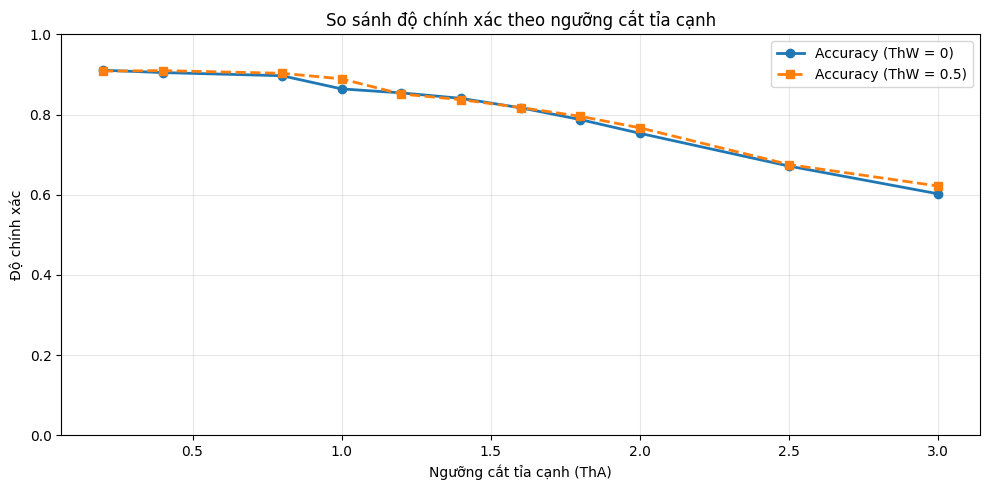

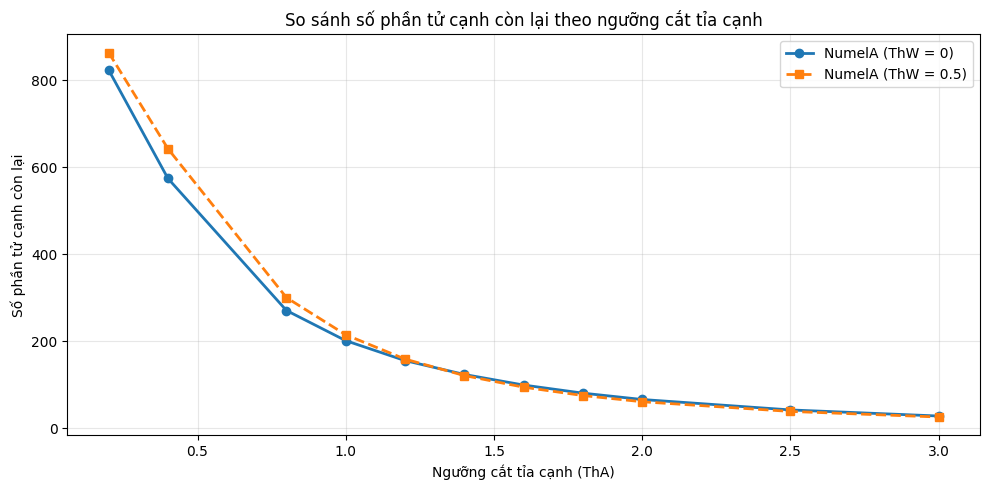

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 2. Hàm chuẩn hoá dataframe
# =========================================================
def prepare_dataframe(data):
    data = data.copy()

    # Chuẩn hoá tên cột
    data.columns = [c.strip() for c in data.columns]

    # Chuẩn hoá text
    for col in ["Data", "Model"]:
        if col in data.columns:
            data[col] = data[col].astype(str).str.strip()

    # Chuyển cột số
    numeric_cols = [
        "Seed", "ThA", "ThW", "Acc", "Cn", "EP",
        "Ttrain", "Ctrain", "Ttest", "CTest", "NumelA", "NumelW"
    ]
    for col in numeric_cols:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce")

    # Xoá dòng trùng theo (ThA, ThW), giữ dòng đầu
    if "ThA" in data.columns and "ThW" in data.columns:
        data = data.drop_duplicates(subset=["ThA", "ThW"], keep="first").copy()

    # Bổ sung FLOPs
    if "CTest" in data.columns:
        data["FLOPs_test"] = 2 * data["CTest"]

    if "Ctrain" in data.columns:
        data["FLOPs_train"] = 2 * data["Ctrain"]

    # Sắp xếp
    sort_cols = [c for c in ["ThW", "ThA"] if c in data.columns]
    if sort_cols:
        data = data.sort_values(sort_cols).reset_index(drop=True)

    return data

df = prepare_dataframe(df)
df1 = prepare_dataframe(df1)

# =========================================================
# 3. Lọc dữ liệu
# =========================================================
df_tha_0 = df[np.isclose(df["ThW"], 0.0)].sort_values("ThA").copy()
df_tha_05 = df1[np.isclose(df1["ThW"], 0.5)].sort_values("ThA").copy()

# =========================================================
# 4. Gộp dữ liệu theo ThA để vẽ cùng trục
# =========================================================
plot_df = pd.merge(
    df_tha_0[["ThA", "Acc", "NumelA"]].rename(columns={
        "Acc": "Acc_ThW_0",
        "NumelA": "NumelA_ThW_0"
    }),
    df_tha_05[["ThA", "Acc", "NumelA"]].rename(columns={
        "Acc": "Acc_ThW_05",
        "NumelA": "NumelA_ThW_05"
    }),
    on="ThA",
    how="inner"
).sort_values("ThA").reset_index(drop=True)

print("=== Dữ liệu dùng để vẽ ===")
print(plot_df)

# =========================================================
# 5. Chart 1: Accuracy
# =========================================================
plt.figure(figsize=(10, 5))

plt.plot(
    plot_df["ThA"],
    plot_df["Acc_ThW_0"],
    marker="o",
    linewidth=2,
    label="Accuracy (ThW = 0)"
)

plt.plot(
    plot_df["ThA"],
    plot_df["Acc_ThW_05"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Accuracy (ThW = 0.5)"
)

plt.xlabel("Ngưỡng cắt tỉa cạnh (ThA)")
plt.ylabel("Độ chính xác")
plt.ylim(0, 1)
plt.title("So sánh độ chính xác theo ngưỡng cắt tỉa cạnh")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 6. Chart 2: NumelA
# =========================================================
plt.figure(figsize=(10, 5))

plt.plot(
    plot_df["ThA"],
    plot_df["NumelA_ThW_0"],
    marker="o",
    linewidth=2,
    label="NumelA (ThW = 0)"
)

plt.plot(
    plot_df["ThA"],
    plot_df["NumelA_ThW_05"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="NumelA (ThW = 0.5)"
)

plt.xlabel("Ngưỡng cắt tỉa cạnh (ThA)")
plt.ylabel("Số phần tử cạnh còn lại")
plt.title("So sánh số phần tử cạnh còn lại theo ngưỡng cắt tỉa cạnh")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()